In [1]:
import pandas as pd
import numpy as np
from functools import reduce
data_dir = '../output/iPhone17/'

In [2]:
def load_counts(filename, value_name):
    return (
        pd.read_csv(data_dir + filename)['chosen_profile_id']
        .value_counts()
        .rename_axis('chosen_profile_id')
        .reset_index(name=value_name)
    )

df_in = load_counts('represents104_allcomb.csv', 'I_in')
df_16 = load_counts('represents104_allcomb_re16.csv', 'I_re16')
df_sum = load_counts('represents104_allcomb_summacrumoriPhone17.csv', 'I_sum')
df_full = load_counts('represents104_allcomb_macrumoriPhone17.csv', 'I_full')
df_RAG = load_counts('represents104_allcomb_RAG.csv', 'I_RAG')
dfs = [df_in, df_16, df_sum, df_full, df_RAG]
result = reduce(lambda left, right: pd.merge(left, right, on='chosen_profile_id', how='outer'), dfs).fillna(0)
result.set_index('chosen_profile_id', inplace=True)
result = result.astype(int)/103

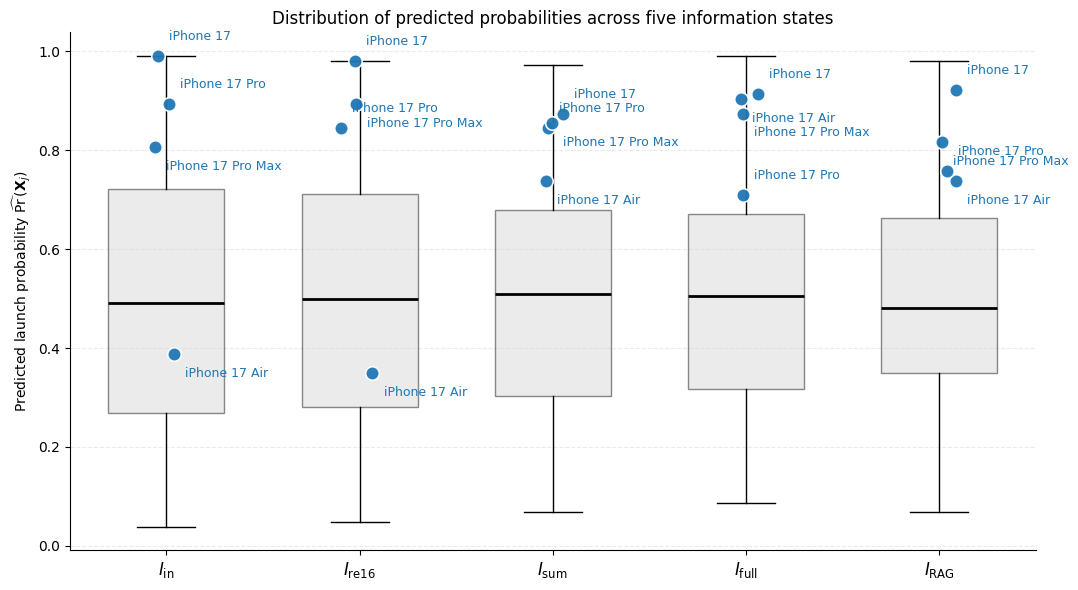

In [49]:
import matplotlib.pyplot as plt

plot_cols = result.columns.tolist()
iphone17_products = ['iPhone 17', 'iPhone 17 Air', 'iPhone 17 Pro', 'iPhone 17 Pro Max']
iphone17_df = result.loc[iphone17_products].copy()

plot_data = [result[col].dropna() for col in plot_cols]
xpos = np.arange(1, len(plot_cols) + 1)
latex_labels = [
    rf"$I_{{\text{{{col.split('I_', 1)[1]}}}}}$" if col.startswith('I_') else col
    for col in plot_cols
]

label_offsets = {
    'iPhone 17': (8, 14),
    'iPhone 17 Air': (8, -14),
    'iPhone 17 Pro': (8, 14),
    'iPhone 17 Pro Max': (8, -14),
}

np.random.seed(123)

fig, ax = plt.subplots(figsize=(11, 6))

bp = ax.boxplot(
    plot_data,
    positions=xpos,
    widths=0.6,
    patch_artist=True,
    showfliers=False,
)

for box in bp['boxes']:
    box.set(facecolor='#D3D3D3', alpha=0.45, edgecolor='black')
for median in bp['medians']:
    median.set(color='black', linewidth=2)

for i, col in enumerate(plot_cols, start=1):
    x_jitter = i + np.random.normal(0, 0.04, size=len(iphone17_df))
    y_vals = iphone17_df[col].values

    ax.scatter(
        x_jitter,
        y_vals,
        s=95,
        color='#1F77B4', #D62728',
        edgecolor='white',
        linewidth=1.2,
        alpha=0.95,
        zorder=3,
    )

    for x, y, label in zip(x_jitter, y_vals, iphone17_df.index):
        dx, dy = label_offsets.get(label, (8, 0))
        ax.annotate(
            label,
            (x, y),
            xytext=(dx, dy),
            textcoords='offset points',
            fontsize=9,
            va='center',
            color= '#1F77B4' #D62728',
        )

ax.set_ylabel(r'Predicted launch probability $\widehat{\Pr}(\mathbf{X}_j)$')
ax.set_xticks(xpos)
ax.set_xticklabels(latex_labels, fontsize=12)
ax.set_title('Distribution of predicted probabilities across five information states')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.25)
# ax.legend(loc='upper right', frameon=False)
plt.tight_layout()
plt.show()


In [54]:
iphone17_products = [
    'iPhone 17',
    'iPhone 17 Air',
    'iPhone 17 Pro',
    'iPhone 17 Pro Max',
]

info_cols = ['I_in', 'I_re16', 'I_sum', 'I_full', 'I_RAG']

table_df = result.loc[iphone17_products, info_cols].copy()
median_row = result[info_cols].median().to_frame().T
median_row.index = ['Median of $\widehat{\Pr}(\mathbf{X}_j)$']
table_df = pd.concat([table_df, median_row], axis=0)
table_df.columns = [
    rf"$I_{{\text{{{col.split('I_', 1)[1]}}}}}$" if col.startswith('I_') else col
    for col in table_df.columns
]
table_df = table_df.map(lambda x: f"{x:.3f}")

lines = []
lines.append(r"\begin{table}[h]")
lines.append(r"    \centering")
lines.append(r"    \begin{threeparttable}")
lines.append(r"        \caption{Predicted launch probabilities for the iPhone 17 lineup across five information states}")
lines.append(r"        \label{tab:iphone17-info-states}")
lines.append(r"        \begin{tabular}{lccccc}")
lines.append(r"            \toprule")
lines.append(r"            Item & $I_{\text{in}}$ & $I_{\text{re16}}$ & $I_{\text{sum}}$ & $I_{\text{full}}$ & $I_{\text{RAG}}$ \\")
lines.append(r"            \midrule")

for idx, row in table_df.iterrows():
    row_str = ' & '.join([idx] + row.tolist()) + r' \\'
    lines.append('            ' + row_str)

lines.append(r"            \bottomrule")
lines.append(r"        \end{tabular}")
lines.append(r"        \begin{tablenotes}")
lines.append(r"            \small")
lines.append(r"            \item Entries report predicted launch probability $\widehat{\Pr}(\mathbf{X}_j)$ for each iPhone 17 profile under different information states.")
lines.append(r"        \end{tablenotes}")
lines.append(r"    \end{threeparttable}")
lines.append(r"\end{table}")

latex_table = '\n'.join(lines)
print(latex_table)


\begin{table}[h]
    \centering
    \begin{threeparttable}
        \caption{Predicted launch probabilities for the iPhone 17 lineup across five information states}
        \label{tab:iphone17-info-states}
        \begin{tabular}{lccccc}
            \toprule
            Item & $I_{\text{in}}$ & $I_{\text{re16}}$ & $I_{\text{sum}}$ & $I_{\text{full}}$ & $I_{\text{RAG}}$ \\
            \midrule
            iPhone 17 & 0.990 & 0.981 & 0.874 & 0.913 & 0.922 \\
            iPhone 17 Air & 0.388 & 0.350 & 0.738 & 0.903 & 0.738 \\
            iPhone 17 Pro & 0.893 & 0.845 & 0.845 & 0.709 & 0.757 \\
            iPhone 17 Pro Max & 0.806 & 0.893 & 0.854 & 0.874 & 0.816 \\
            Median of $\widehat{\Pr}(\mathbf{X}_j)$ & 0.490 & 0.500 & 0.510 & 0.505 & 0.481 \\
            \bottomrule
        \end{tabular}
        \begin{tablenotes}
            \small
            \item Entries report predicted launch probability $\widehat{\Pr}(\mathbf{X}_j)$ for each iPhone 17 profile under different informa

<>:12: SyntaxWarning: invalid escape sequence '\w'
<>:12: SyntaxWarning: invalid escape sequence '\w'
[kernel-temp-path]/ipykernel_20948/1878261004.py:12: SyntaxWarning: invalid escape sequence '\w'
  median_row.index = ['Median of $\widehat{\Pr}(\mathbf{X}_j)$']


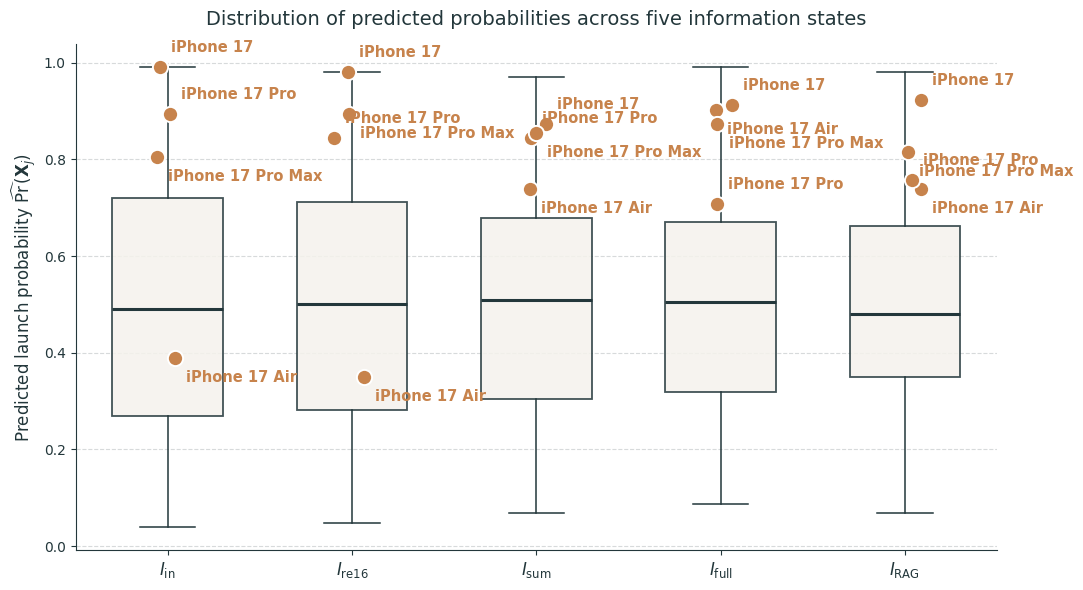

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Presentation theme colors
MY_PRIMARY = "#23373B"        # dark green-gray
M_LIGHT_BROWN = "#C7834C"     # orange-brown for real profiles
# BOX_FILL = "#EEE9E2"          # lighter neutral fill so orange stands out more
BOX_FILL = "#F5F2ED"
MY_GRID = MY_PRIMARY

plot_cols = result.columns.tolist()
iphone17_products = ["iPhone 17", "iPhone 17 Air", "iPhone 17 Pro", "iPhone 17 Pro Max"]
iphone17_df = result.loc[iphone17_products].copy()

plot_data = [result[col].dropna() for col in plot_cols]
xpos = np.arange(1, len(plot_cols) + 1)

latex_labels = [
    rf"$I_{{\text{{{col.split('I_', 1)[1]}}}}}$" if col.startswith("I_") else col
    for col in plot_cols
]

label_offsets = {
    "iPhone 17": (8, 14),
    "iPhone 17 Air": (8, -14),
    "iPhone 17 Pro": (8, 14),
    "iPhone 17 Pro Max": (8, -14),
}

np.random.seed(123)

fig, ax = plt.subplots(figsize=(11, 6))

# Transparent background
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

bp = ax.boxplot(
    plot_data,
    positions=xpos,
    widths=0.6,
    patch_artist=True,
    showfliers=False,
)

# Box styling: lighter fill for better contrast with orange points
for box in bp["boxes"]:
    box.set(
        facecolor=BOX_FILL,
        alpha=0.85,
        edgecolor=MY_PRIMARY,
        linewidth=1.3,
    )

for whisker in bp["whiskers"]:
    whisker.set(color=MY_PRIMARY, linewidth=1.1)

for cap in bp["caps"]:
    cap.set(color=MY_PRIMARY, linewidth=1.1)

for median in bp["medians"]:
    median.set(color=MY_PRIMARY, linewidth=2.2)

# Real iPhone 17 profiles
for i, col in enumerate(plot_cols, start=1):
    x_jitter = i + np.random.normal(0, 0.04, size=len(iphone17_df))
    y_vals = iphone17_df[col].values

    ax.scatter(
        x_jitter,
        y_vals,
        s=120,                 # larger points
        color=M_LIGHT_BROWN,
        edgecolor="white",
        linewidth=1.4,
        alpha=1.0,
        zorder=3,
    )

    for x, y, label in zip(x_jitter, y_vals, iphone17_df.index):
        dx, dy = label_offsets.get(label, (8, 0))
        ax.annotate(
            label,
            (x, y),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=10.5,      # larger text
            fontweight="bold",  # bold text
            va="center",
            color=M_LIGHT_BROWN,
        )

ax.set_ylabel(
    r"Predicted launch probability $\widehat{\Pr}(\mathbf{X}_j)$",
    fontsize=12,
    color=MY_PRIMARY,
)

ax.set_xticks(xpos)
ax.set_xticklabels(latex_labels, fontsize=12, color=MY_PRIMARY)

ax.set_title(
    "Distribution of predicted probabilities across five information states",
    fontsize=14,
    color=MY_PRIMARY,
    pad=14,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(MY_PRIMARY)
ax.spines["bottom"].set_color(MY_PRIMARY)

ax.tick_params(axis="both", colors=MY_PRIMARY)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.18,
    color=MY_GRID,
)

plt.tight_layout()

plt.savefig(
    "iphone17_predicted_probabilities.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight",
)

plt.show()

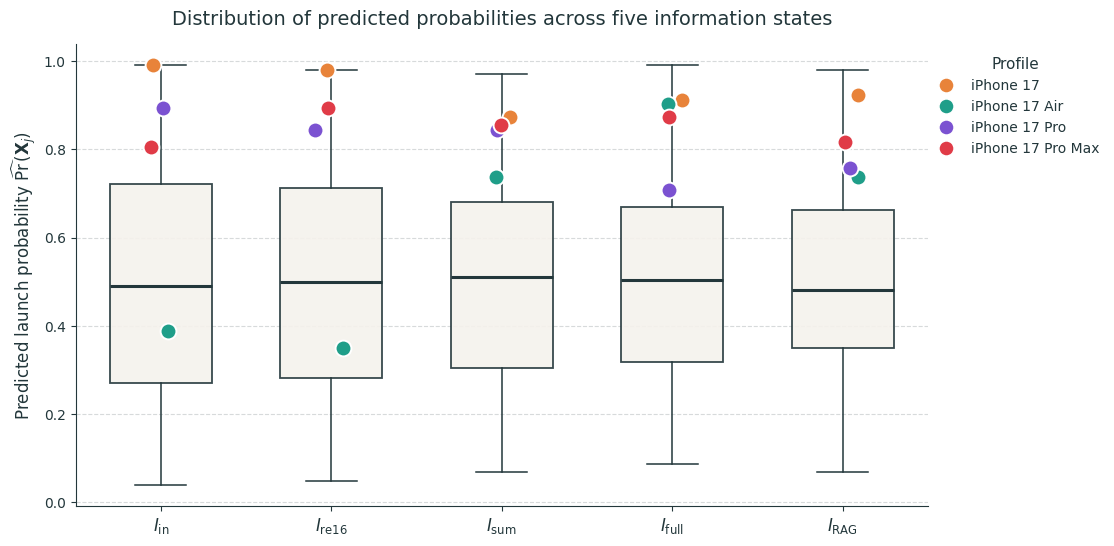

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Presentation theme colors
MY_PRIMARY = "#23373B"      # dark green-gray
BOX_FILL = "#F5F2ED"        # very light neutral fill
MY_GRID = MY_PRIMARY

# 鲜亮、区分度高的四个颜色
profile_colors = {
    "iPhone 17":         "#E8833A",  # vivid orange
    "iPhone 17 Air":     "#1F9E89",  # vivid teal
    "iPhone 17 Pro":     "#7B52D1",  # vivid purple
    "iPhone 17 Pro Max": "#E03B47",  # vivid red
}

plot_cols = result.columns.tolist()
iphone17_products = ["iPhone 17", "iPhone 17 Air", "iPhone 17 Pro", "iPhone 17 Pro Max"]
iphone17_df = result.loc[iphone17_products].copy()

plot_data = [result[col].dropna() for col in plot_cols]
xpos = np.arange(1, len(plot_cols) + 1)

latex_labels = [
    rf"$I_{{\text{{{col.split('I_', 1)[1]}}}}}$" if col.startswith("I_") else col
    for col in plot_cols
]

np.random.seed(123)
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

bp = ax.boxplot(
    plot_data,
    positions=xpos,
    widths=0.6,
    patch_artist=True,
    showfliers=False,
)
for box in bp["boxes"]:
    box.set(facecolor=BOX_FILL, alpha=0.9, edgecolor=MY_PRIMARY, linewidth=1.3)
for whisker in bp["whiskers"]:
    whisker.set(color=MY_PRIMARY, linewidth=1.1)
for cap in bp["caps"]:
    cap.set(color=MY_PRIMARY, linewidth=1.1)
for median in bp["medians"]:
    median.set(color=MY_PRIMARY, linewidth=2.2)

# 画四个 real profile 的点（不再加点边标注）
for i, col in enumerate(plot_cols, start=1):
    x_jitter = i + np.random.normal(0, 0.04, size=len(iphone17_df))
    y_vals = iphone17_df[col].values
    labels = iphone17_df.index.tolist()
    for x, y, label in zip(x_jitter, y_vals, labels):
        c = profile_colors[label]
        ax.scatter(
            x, y,
            s=130,
            color=c,
            edgecolor="white",
            linewidth=1.4,
            alpha=1.0,
            zorder=3,
        )

# Legend：放在画布外、无边框
legend_handles = [
    Line2D(
        [0], [0],
        marker="o", linestyle="None", markersize=11,
        markerfacecolor=color, markeredgecolor="white", markeredgewidth=1.2,
        label=name,
    )
    for name, color in profile_colors.items()
]
legend = ax.legend(
    handles=legend_handles,
    title="Profile",
    loc="upper left",
    bbox_to_anchor=(0.99, 1.0),   # 离主图更近（原来是 1.02）
    frameon=False,
    fontsize=10,
    title_fontsize=11,
)
legend.get_title().set_color(MY_PRIMARY)
for txt in legend.get_texts():
    txt.set_color(MY_PRIMARY)

ax.set_ylabel(
    r"Predicted launch probability $\widehat{\Pr}(\mathbf{X}_j)$",
    fontsize=12, color=MY_PRIMARY,
)
ax.set_xticks(xpos)
ax.set_xticklabels(latex_labels, fontsize=12, color=MY_PRIMARY)
ax.set_title(
    "Distribution of predicted probabilities across five information states",
    fontsize=14, color=MY_PRIMARY, pad=14,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(MY_PRIMARY)
ax.spines["bottom"].set_color(MY_PRIMARY)
ax.tick_params(axis="both", colors=MY_PRIMARY)
ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.18, color=MY_GRID)

plt.savefig(
    "iphone17_predicted_probabilities.png",
    dpi=300, transparent=True, bbox_inches="tight",
)
plt.show()